# Experiment 002 — Pretrained TrOCR on IAM

Evaluate Microsoft's pretrained `microsoft/trocr-base-handwritten` model on the established writer-independent IAM test split without additional fine-tuning.

This notebook evaluates **all usable (`status=ok`) test lines** after applying the IAM split definitions.

Metrics:
- Character Error Rate (CER)
- Word Error Rate (WER)
- Exact Match


## 1. Setup

In [1]:
from pathlib import Path
import sys
import json

cwd = Path.cwd().resolve()

if (cwd / "src").exists() and (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root. Open this notebook from the repository or notebooks/ directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)


Project root: /Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project
Python: /Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project/.venv/bin/python


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from tqdm.auto import tqdm
from src.metrics import calculate_cer, calculate_wer, exact_field_accuracy
print("PyTorch:", torch.__version__)


/Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.0


## 2. Load IAM Test Split


In [3]:
CSV_PATH = PROJECT_ROOT / "data" / "iam" / "test.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"IAM test CSV was not found:\n{CSV_PATH}\n\n"
        "Run src/create_iam_sample.py and src/create_iam_splits.py first."
    )

df = pd.read_csv(CSV_PATH)

required_columns = {"id", "image", "text"}
missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

print("CSV:", CSV_PATH)
print("Usable IAM test samples:", len(df))
df.head()


CSV: /Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project/data/iam/test.csv
Usable IAM test samples: 1480


,id,image,text
0,m01-049-00,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,He rose from his breakfast-nook bench
1,m01-049-01,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,"and came into the livingroom , where"
2,m01-049-02,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,Heather and Steve stood aghast at
3,m01-049-03,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,"his entrance . He came , almost falling"
4,m01-049-04,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,"forward in an ungainly shuffle , neck"


In [4]:
missing_images = [
    p for p in df["image"]
    if not Path(p).exists()
]

if missing_images:
    print(f"WARNING: {len(missing_images)} test image paths do not exist.")
    print("First missing path:", missing_images[0])
else:
    print(f"All {len(df)} test image paths verified successfully.")


All 1480 test image paths verified successfully.


## 3. Display Sample

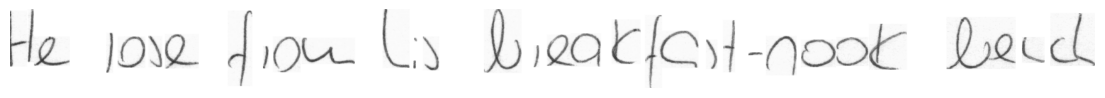

Sample ID: m01-049-00
Ground Truth:
He rose from his breakfast-nook bench


In [5]:
sample = df.iloc[0]
image_path = Path(sample["image"])
image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(14, 3))
plt.imshow(image)
plt.axis("off")
plt.show()
print("Sample ID:", sample.get("id", image_path.stem))
print("Ground Truth:")
print(sample["text"])


## 4. Load Pretrained TrOCR

In [6]:
MODEL_NAME = "microsoft/trocr-base-handwritten"
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)
model.eval()
print("Model:", MODEL_NAME)
print("Device:", device)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: microsoft/trocr-base-handwritten
Device: mps


## 5. Run Inference

In [7]:
pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
with torch.no_grad():
    generated_ids = model.generate(pixel_values)
prediction = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Prediction:")
print(prediction)


Prediction:
He rose from his breakfast-nook bench


## 6. Ground Truth vs Prediction

In [8]:
reference = str(sample["text"])
print("Ground Truth:")
print(reference)
print("\nPrediction:")
print(prediction)


Ground Truth:
He rose from his breakfast-nook bench

Prediction:
He rose from his breakfast-nook bench


## 7. Calculate CER

In [9]:
sample_cer = calculate_cer(reference, prediction)
print(f"CER: {sample_cer:.4f}")


CER: 0.0000


## 8. Calculate WER

In [10]:
sample_wer = calculate_wer(reference, prediction)
sample_exact = exact_field_accuracy(reference, prediction)
print(f"WER:   {sample_wer:.4f}")
print(f"Exact: {sample_exact}")


WER:   0.0000
Exact: 1


## 9. Evaluate Complete IAM Test Split


In [11]:
N = len(df)
print(f"Evaluating complete usable IAM test split: {N} samples")


Evaluating complete usable IAM test split: 1480 samples


In [12]:
results = []

for _, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Evaluating IAM test set"
):
    image_path = Path(row["image"])
    reference = str(row["text"])

    try:
        image = Image.open(image_path).convert("RGB")

        pixel_values = processor(
            images=image,
            return_tensors="pt"
        ).pixel_values.to(device)

        with torch.no_grad():
            generated_ids = model.generate(pixel_values)

        prediction = processor.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )[0]

        results.append({
            "sample": row["id"],
            "ground_truth": reference,
            "prediction": prediction,
            "cer": calculate_cer(reference, prediction),
            "wer": calculate_wer(reference, prediction),
            "exact": exact_field_accuracy(reference, prediction),
        })

    except Exception as exc:
        print(f"Skipping {row['id']}: {exc}")

results_df = pd.DataFrame(results)

print()
print("Successfully evaluated:", len(results_df))
results_df.head()


Evaluating IAM test set: 100%|██████████| 1480/1480 [53:21<00:00,  2.16s/it]   


Successfully evaluated: 1480


,sample,ground_truth,prediction,cer,wer,exact
0,m01-049-00,He rose from his breakfast-nook bench,He rose from his breakfast-nook bench,0.000000,0.000000,1
1,m01-049-01,"and came into the livingroom , where","and come into the European , where",0.305556,0.285714,0
2,m01-049-02,Heather and Steve stood aghast at,Heather and Neue stood again on,0.242424,0.500000,0
3,m01-049-03,"his entrance . He came , almost falling","his entrance . He came , album falling",0.102564,0.125000,0
4,m01-049-04,"forward in an ungainly shuffle , neck","found in an ungainly shuffle , neck",0.108108,0.142857,0


## 10. Aggregate Results

In [13]:
if results_df.empty:
    raise RuntimeError("No samples were evaluated successfully.")

summary = {
    "model": MODEL_NAME,
    "evaluation_set": "IAM writer-independent test split (usable status=ok lines)",
    "samples_evaluated": int(len(results_df)),
    "average_cer": float(results_df["cer"].mean()),
    "average_wer": float(results_df["wer"].mean()),
    "exact_matches": int(results_df["exact"].sum()),
    "exact_match_rate": float(results_df["exact"].mean()),
}

print(f"Samples evaluated : {summary['samples_evaluated']}")
print(f"Average CER       : {summary['average_cer']:.4f}")
print(f"Average WER       : {summary['average_wer']:.4f}")
print(f"Exact matches     : {summary['exact_matches']}")
print(f"Exact match rate  : {summary['exact_match_rate']:.2%}")


Samples evaluated : 1480
Average CER       : 0.0333
Average WER       : 0.0863
Exact matches     : 842
Exact match rate  : 56.89%


## 11. Best Predictions

In [14]:
best_predictions = results_df.sort_values(
    ["cer", "wer"],
    ascending=[True, True]
).head(10)

best_predictions[[
    "sample", "ground_truth", "prediction", "cer", "wer", "exact"
]]


,sample,ground_truth,prediction,cer,wer,exact
0,m01-049-00,He rose from his breakfast-nook bench,He rose from his breakfast-nook bench,0.0,0.0,1
6,m01-049-06,"Then , abruptly , he drew himself up","Then , abruptly , he drew himself up",0.0,0.0,1
11,m01-060-03,"transcendent event , the exalted desire of all","transcendent event , the exalted desire of all",0.0,0.0,1
12,m01-060-04,mankind through all ages ! The Kingdom of the,mankind through all ages ! The Kingdom of the,0.0,0.0,1
14,m01-060-06,upward and shook his head slowly from,upward and shook his head slowly from,0.0,0.0,1
16,m01-079-01,abroad ; and no pedestrian to cross his path n...,abroad ; and no pedestrian to cross his path n...,0.0,0.0,1
17,m01-079-02,at an intersection for the light to change . A...,at an intersection for the light to change . A...,0.0,0.0,1
18,m01-079-03,apartment he garaged his car and then stood,apartment he garaged his car and then stood,0.0,0.0,1
20,m01-084-01,Steve awakened early and switched on,Steve awakened early and switched on,0.0,0.0,1
21,m01-084-03,The set lighted-up but gave only a low,The set lighted-up but gave only a low,0.0,0.0,1


## 12. Worst Predictions

In [15]:
worst_predictions = results_df.sort_values(
    ["cer", "wer"],
    ascending=[False, False]
).head(10)

worst_predictions[[
    "sample", "ground_truth", "prediction", "cer", "wer", "exact"
]]


,sample,ground_truth,prediction,cer,wer,exact
1302,p03-033-04,"suppose , to meet me for supper somewhere ? "" ...","Surname , is met at the ROH Superior Adventure...",0.603774,0.833333,0
331,m04-038-04,Dinas Motor Omnibus Co. to ask what had happen...,"Dennis Hunter Dravides , her , Her wish that h...",0.578947,1.000000,0
1439,p06-047-07,"his # prescription pad , and","his # # # if pressure script on paid , and",0.535714,1.166667,0
1155,p02-022-04,laid his hand on hers . Gay smiled at him,David Luis blamed on Nero . Glory reunited out...,0.487805,0.700000,0
1431,p06-030-08,you are satisfied . ',"you are rats "" pedal .",0.428571,0.800000,0
1425,p03-189-00,Sentence Database P03-189,instance Database # # P. 3-189,0.400000,1.666667,0
1440,p06-047-08,"# scribble on it . Then ,","still # trouble on it . Then ,",0.400000,0.285714,0
5,m01-049-05,"thrust out , arms dangling loosely .","themwell , and , arms changing loosely .",0.388889,0.571429,0
324,m04-030-02,"She was already up the bus steps , and the bus...","She was already run there has stops , and ther...",0.324324,0.529412,0
737,n02-157-07,"to all kin' o' boats , wid d'ose big , big","to all trial of Scouts , which chose big , big",0.309524,0.454545,0


## Save Experiment Outputs

In [16]:
RUN_NAME = "iam_test"

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "exp002"
    / RUN_NAME
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results_df.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
best_predictions.to_csv(OUTPUT_DIR / "best_predictions.csv", index=False)
worst_predictions.to_csv(OUTPUT_DIR / "worst_predictions.csv", index=False)

with open(OUTPUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved EXP002 IAM test results to:")
print(OUTPUT_DIR)


Saved EXP002 IAM test results to:
/Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project/outputs/exp002/iam_test


## 13. Observations

Complete this section after the full test-set evaluation.

### Dataset Filtering

- IAM line annotations: 13,353
- Usable lines (`status=ok`): 11,344
- Lines excluded (`status=err`): 2,009
- Usable writer-independent test lines: 1,480
- Missing `status=ok` test IDs: 0
- Form-level overlap across generated splits: none detected

### Quantitative Results

- Samples evaluated:
- Average CER:
- Average WER:
- Exact Matches:
- Exact Match Rate:

### Error Analysis

- Strongest predictions:
- Weakest predictions:
- Character-level errors:
- Word-level errors:
- Punctuation / spacing errors:
- Language-like substitutions:

### Interpretation

Compare this established test-set baseline with the earlier exploratory N=20, N=50, and N=100 runs.
